# Importação das Bibliotecas




In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.classify import NaiveBayesClassifier
from nltk.tokenize import word_tokenize
import string
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Carregando os dados

In [3]:
df = pd.read_csv('comentario_label.csv')
df.head(3)

,Comentário,rotulo
0,"Entrega rápida, mas o produto veio danificado.",Negativo
1,Qualidade abaixo do esperado.,negativo
2,"Não gostei, esperava mais.",negativa


# Gerar um grafico para compreender a estrutura desses rolutos

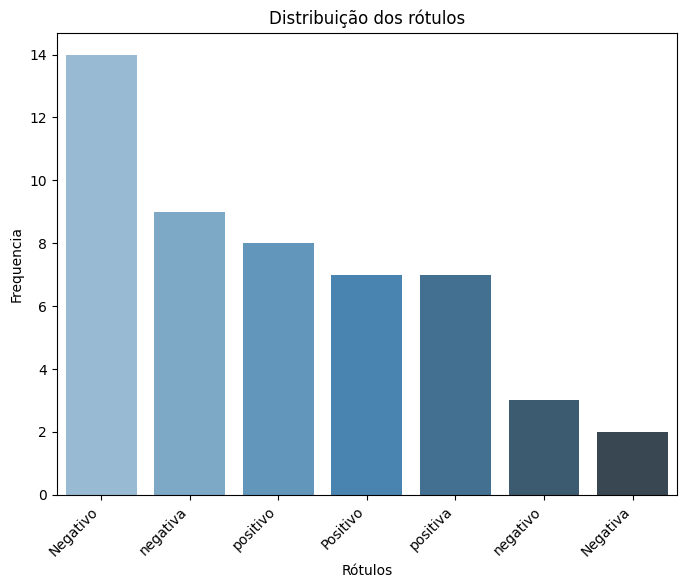

In [4]:
contagem_rotulos = df['rotulo'].value_counts()

# Plotar a distribuição desses rótulos
plt.figure(figsize=(8,6))
sns.barplot(x=contagem_rotulos.index, y=contagem_rotulos.values, palette='Blues_d', hue=contagem_rotulos.index, legend=False)

plt.title("Distribuição dos rótulos")
plt.ylabel("Frequencia")
plt.xlabel("Rótulos")
plt.xticks(rotation=45, ha='right')

plt.show()

# Tratar e Padronizar os rótulos

In [5]:
def padronizar_rotulo(rotulo):
    rotulo = rotulo.lower()
    if rotulo.startswith('negat'):
        return 'negativo'
    elif rotulo.startswith('posit'):
        return 'positivo'
    return rotulo

# Preparar os dados para Treinamento

In [6]:
import time
# Opção A
inicio = time.time()
dados_treinamento = [(row['Comentário'], padronizar_rotulo(row['rotulo'])) for index, row in df.iterrows()]
fim = time.time()
tempo_processamento = fim - inicio
print(f'O tempo de processamento eh = {tempo_processamento}')

O tempo de processamento eh = 0.0045816898345947266


# Extraindo as features do comentario

O modelo Naive Bayes do NLTK trabalha com um formato de entrada onde:

Cada chave representa uma feature (característica, neste caso uma palavra).

O valor True indica que essa palavra está presente no texto.

Ou seja, o dicionário mostra quais palavras aparecem na frase.

In [8]:
def extrair_features(comentario):
    stops = stopwords.words('portuguese')
    tokens = word_tokenize(comentario.lower())
    palavras_sem_stopwords = [token for token in tokens if token not in stops]
    palavras_sem_pontuacao = [new_token for new_token in palavras_sem_stopwords if new_token not in string.punctuation]
    features = {palavra: True for palavra in palavras_sem_pontuacao}
    return features

# Transformar os dados de treinamento nas features

In [9]:
features_treinamento = [(extrair_features(comentario), rotulo) for (comentario, rotulo) in dados_treinamento]

# Treinamento do Modelo

In [10]:
classificador = NaiveBayesClassifier.train(features_treinamento)

# Salvar Modelo


In [ ]:
import joblib
# Assumindo que 'classificador' é o seu modelo treinado
nome_modelo = "naive_bayes_classificador.pkl" # Mudança da extensão
joblib.dump(classificador, nome_modelo)
print("Modelo Salvo com sucesso usando Joblib!")

Modelo Salvo com sucesso!


# Analiando o sentimento novos sentimentos

In [12]:
def analisar_sentimento_nltk(comentarios):
    for comentario in comentarios:
        features = extrair_features(comentario)
        rotulo = classificador.classify(features)
        print(f"Comentário: '{comentario}' -> Sentimento: {rotulo}")

In [13]:
# Testar com novos comentários
comentarios_testes = [
    "Produto excelente, muito satisfeito!",
    "Não gostei do produto, veio com defeito.",
    "É razoável, mas não vale o preço.",
    "Estou muito feliz com a minha compra.",
    "Péssima experiência, não recomendo!",
    "Excelente",
    "Não gostei",
    "Gostei, mas não gostei",
    "Achei sensacional, não poderia ficar sem essa compra"
]

analisar_sentimento_nltk(comentarios_testes)


Comentário: 'Produto excelente, muito satisfeito!' -> Sentimento: positivo
Comentário: 'Não gostei do produto, veio com defeito.' -> Sentimento: negativo
Comentário: 'É razoável, mas não vale o preço.' -> Sentimento: positivo
Comentário: 'Estou muito feliz com a minha compra.' -> Sentimento: negativo
Comentário: 'Péssima experiência, não recomendo!' -> Sentimento: negativo
Comentário: 'Excelente' -> Sentimento: positivo
Comentário: 'Não gostei' -> Sentimento: negativo
Comentário: 'Gostei, mas não gostei' -> Sentimento: negativo
Comentário: 'Achei sensacional, não poderia ficar sem essa compra' -> Sentimento: negativo
